# Deep Embedded Autoencoder for Cassini CDA Mass Spectra

This notebook implements a **Deep Embedded Autoencoder** to analyze mass spectra from the Cassini Cosmic Dust Analyzer (CDA).

### Why this approach?
Scientific spacecraft data is often high-dimensional, sparse, and noisy. Standard clustering algorithms (like K-Means) often fail on raw data because they struggle with the "curse of dimensionality" and cannot distinguish between important spectral peaks and random instrument noise.

To solve this, we use a **Deep Embedded Autoencoder** with a fully-connected bottleneck architecture to learn a compressed, noise-free representation ("latent space") of the data.

### Architecture Highlights:
- **CNN Encoder**: Captures local peak patterns with shift-invariance
- **Compact Bottleneck**: Forces compression to 10 dimensions for optimal clustering
- **CNN Decoder**: Reconstructs original 1000-bin spectra
- **Clustering Layer**: Optional soft cluster assignments using Student's t-distribution

### Pipeline Steps:

1. **Data Loading**: Load Parquet files containing the spectra5. **Evaluation**: Ground truth metrics (Silhouette, Linear Probe, Reconstruction Error)

2. **Preprocessing**: Savitzky-Golay filtering → log transformation → normalization4. **Training**: Minimize reconstruction error (MSE loss)
3. **Model Architecture**: Deep CNN autoencoder with explicit 10-dim bottleneck

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Configuration
Input_Length = 1000  # Number of bins to resample spectra to
Batch_Size = 128
Learning_Rate = 1e-3
Epochs = 20
Hidden_Dim = 128  # Latent space dimensions (proper bottleneck)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 1. Data Loading
We load the data from a Parquet file. This efficient columnar format allows us to handle large datasets of spectra quickly. We also filter or crop the data to ensure we are only training on valid signals.

### 1.1 Class Analysis
Before training, it is crucial to understand the class imbalance. Real-world space data is dominated by "Noise" or empty impacts. Knowing the distribution helps us interpret why the model might cluster certain things together (e.g., if 90% of data is noise, the model will prioritize learning the shape of noise).

In [2]:
# 1. Load Data
# Adjust the filename as needed based on which file you want to train on
file_path = 'cda_qm_spectra_pre2008277_train_lvl2.parquet'

try:
    df = pd.read_parquet(file_path)
    print(f"Loaded data shape: {df.shape}")
    print(df.head())
    
    # Extract spectral data
    # Based on the output, the column is named 'spectrum'
    if 'spectrum' in df.columns:
        print("Found 'spectrum' column.")
        # Ensure it's a stack of numpy arrays
        spectra_raw = np.stack(df['spectrum'].values)
    else:
        raise ValueError(f"Column 'spectrum' not found. Available columns: {df.columns}")

except Exception as e:
    print(f"Error loading data: {e}")
    raise e

Loaded data shape: (19820, 6)
           sclk   f_desc  event_id  \
0  1.477582e+09  6405615      4035   
1  1.477619e+09  6405615      6860   
2  1.477626e+09  6405615     10363   
3  1.477630e+09  6405615     12290   
4  1.477666e+09  6405615     16489   

                                            spectrum       qi_ampl  class  
0  [-6.986339e-07, 0.0, 0.0, -8.7329244e-07, 5.23...  5.004700e-14  Noise  
1  [-1.7465848e-07, -8.7329244e-07, -1.7465848e-0...  4.182420e-14  3-Car  
2  [-1.7465848e-07, -1.7465848e-07, -1.7465848e-0...  1.700580e-14  3-Car  
3  [-3.4931696e-07, -3.4931696e-07, -3.4931696e-0...  1.312510e-14  3-KNa  
4  [-6.986339e-07, 0.0, -3.4931696e-07, -5.239755...  4.949150e-12  Noise  
Found 'spectrum' column.


Class distribution:
class
Noise    12077
1         4491
2         1015
3          909
?          553
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
2-X          3
X            2
Name: count, dtype: int64

Total number of classes: 16


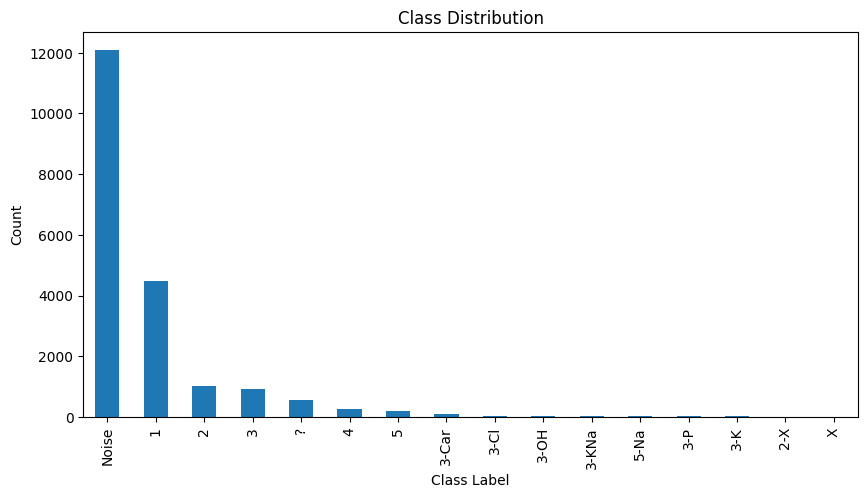

In [3]:
# 1.1 Analyze Classes
if 'class' in df.columns:
    print("Class distribution:")
    class_counts = df['class'].value_counts()
    print(class_counts)
    print(f"\nTotal number of classes: {len(class_counts)}")
    
    # Optional: Plot class distribution
    plt.figure(figsize=(10, 5))
    class_counts.plot(kind='bar')
    plt.title("Class Distribution")
    plt.ylabel("Count")
    plt.xlabel("Class Label")
    plt.show()
else:
    print("Column 'class' not found in dataframe.")

### 2. Preprocessing
We define a function to normalize and reshape the spectra.
*   **Target Length:** 1000 bins. This reduces the input dimensionality while preserving the resolution needed to distinguish mass lines.
*   **Denoising:** Apply Savitzky-Golay filter to smooth out high-frequency noise while preserving peak shapes. This is crucial for mass spectra where sharp peaks contain the chemical information.
*   **Log1p:** $\log(1+x)$ is used to squash the counts. Without this, a single giant peak (e.g., Amplitude 10,000) would render a small but chemically significant peak (Amplitude 10) invisible to the network (it would look like 0.001 after normalization).
*   **Normalization:** Scale to 0-1 range for stable neural network training.

Preprocessing data...
Processed Data Shape: (19820, 1000)
DataLoader created.
PREPROCESSING VISUALIZATION
  Key transformations:
    1. Crop/Pad → Fixed 1000-bin length
    2. Savitzky-Golay → Noise reduction while preserving peaks
    3. Log1p → Compress dynamic range (handle large/small peaks)
    4. Normalization → Scale to [0,1] for stable training

Processed Data Shape: (19820, 1000)
DataLoader created.
PREPROCESSING VISUALIZATION
  Key transformations:
    1. Crop/Pad → Fixed 1000-bin length
    2. Savitzky-Golay → Noise reduction while preserving peaks
    3. Log1p → Compress dynamic range (handle large/small peaks)
    4. Normalization → Scale to [0,1] for stable training



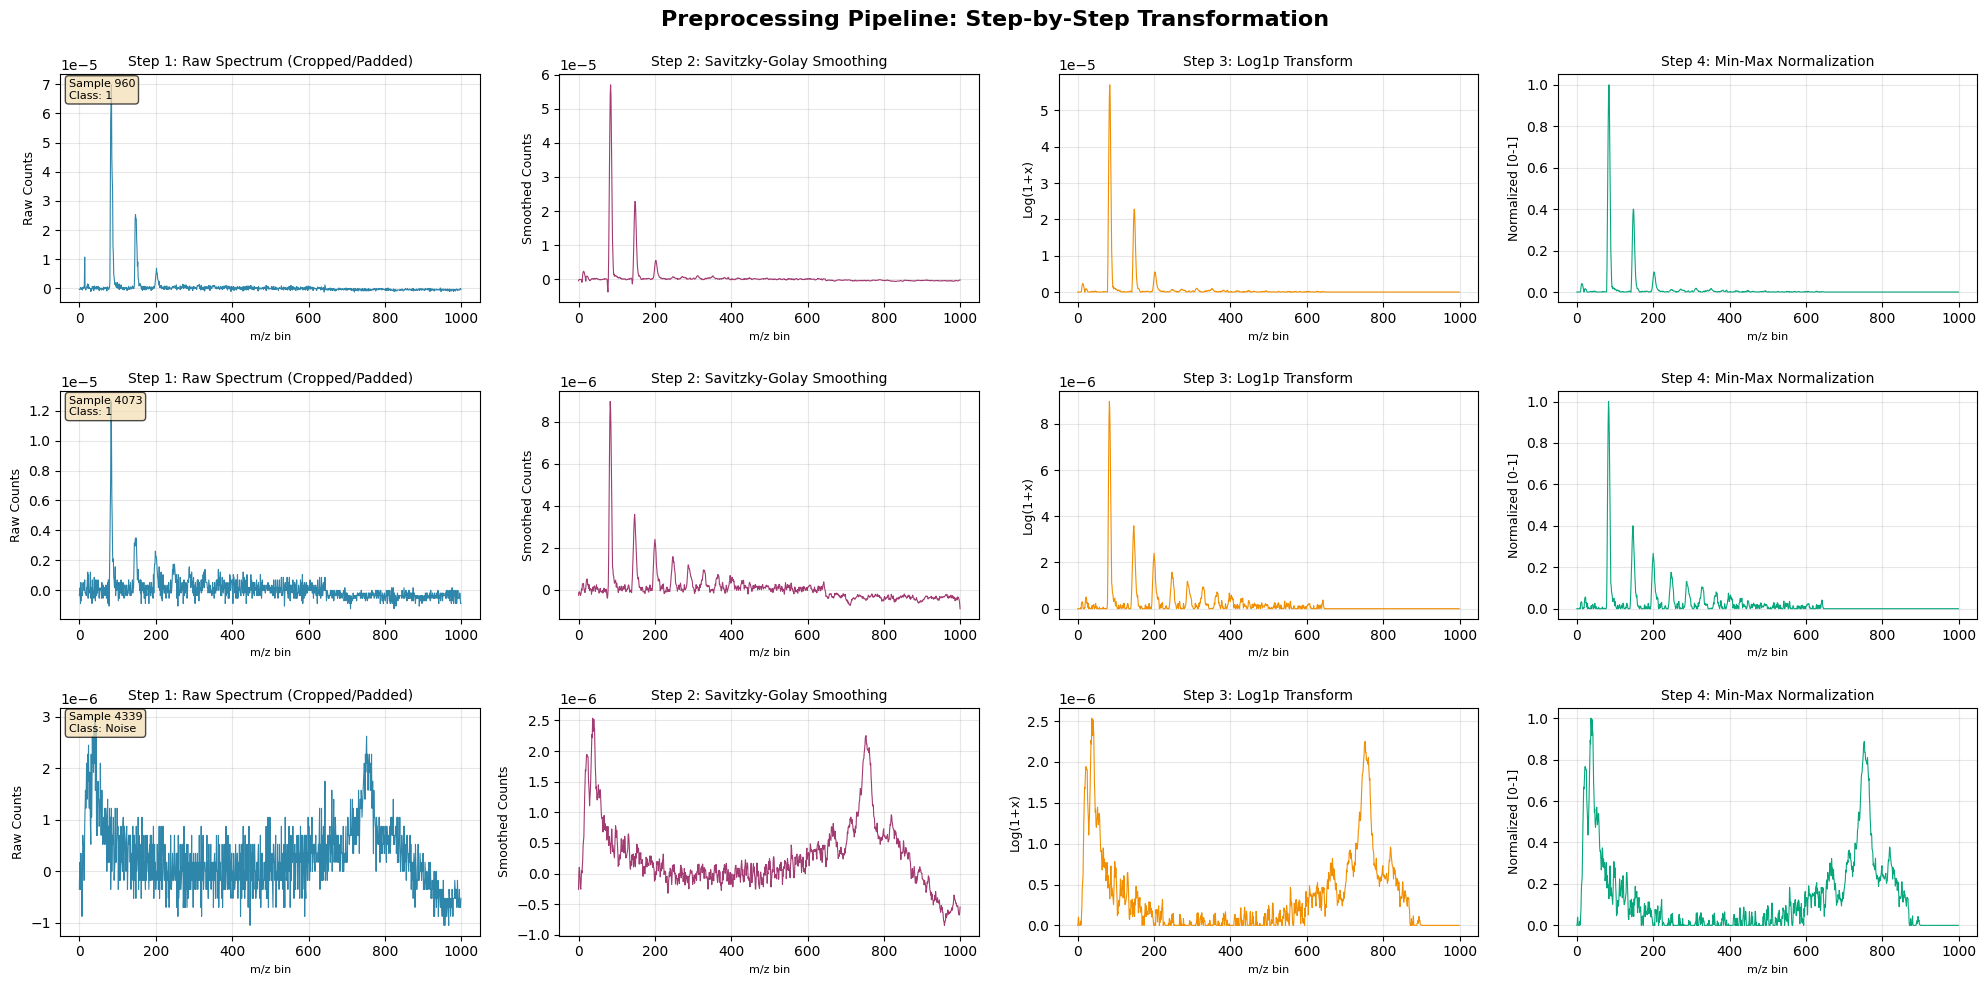


✓ Preprocessing visualization complete


In [4]:
# 2. Preprocessing Function
def preprocess_spectra(spectra, target_length=1000):
    processed = []
    
    for spec in spectra:
        # A. Handling varying lengths (if raw data is list of arrays)
        # Resize or pad/crop to target_length
        if len(spec) >= target_length:
            s = spec[:target_length]
        else:
            s = np.pad(spec, (0, target_length - len(spec)), 'constant')
        
        # B. Denoising with Savitzky-Golay filter
        # This smooths high-frequency noise while preserving peak shapes
        # window_length must be odd and less than array length
        window_length = min(11, len(s) if len(s) % 2 == 1 else len(s) - 1)
        if window_length >= 5:  # Only apply if window is large enough
            s = savgol_filter(s, window_length=window_length, polyorder=3)
        
        # C. Log Transformation (Compress dynamic range)
        # Adding a small epsilon or 1 to avoid log(0) or log(negative) issues if any
        # Assuming minimal value is 0 or -small noise
        s = np.log1p(np.maximum(s, 0))
        
        # D. Max Normalization (Scale to 0-1 range)
        max_val = np.max(s)
        if max_val > 0:
            s = s / max_val
            
        processed.append(s)
        
    return np.array(processed, dtype=np.float32)

# Apply preprocessing
print("Preprocessing data...")
X_train = preprocess_spectra(spectra_raw, target_length=Input_Length)

print(f"Processed Data Shape: {X_train.shape}")

# Convert to PyTorch Tensor
# Add channel dimension: (N, Channels, Length) -> (N, 1, 1000)
dataset = TensorDataset(torch.from_numpy(X_train).unsqueeze(1)) 
loader = DataLoader(dataset, batch_size=Batch_Size, shuffle=True)
print("DataLoader created.")

# Visualize preprocessing effects
print("="*70)
print("PREPROCESSING VISUALIZATION")
print("="*70)
print("  Key transformations:")
print("    1. Crop/Pad → Fixed 1000-bin length")
print("    2. Savitzky-Golay → Noise reduction while preserving peaks")
print("    3. Log1p → Compress dynamic range (handle large/small peaks)")
print("    4. Normalization → Scale to [0,1] for stable training")
print("\n" + "="*70)

# Select 3 random samples to visualize
np.random.seed(42)
sample_indices = np.random.choice(len(spectra_raw), size=3, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
fig.suptitle('Preprocessing Pipeline: Step-by-Step Transformation', fontsize=16, fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('m/z bin', fontsize=8)

for i, idx in enumerate(sample_indices):
    spec = spectra_raw[idx]
    
    # Add sample info
    class_label = df.iloc[idx]['class'] if 'class' in df.columns else 'Unknown'
    
    # Step 1: Raw spectrum
    if len(spec) >= Input_Length:
        s1 = spec[:Input_Length]
    else:
        s1 = np.pad(spec, (0, Input_Length - len(spec)), 'constant')
    
    axes[i, 0].plot(s1, linewidth=0.8, color='#2E86AB')
    axes[i, 0].set_title('Step 1: Raw Spectrum (Cropped/Padded)', fontsize=10)
    axes[i, 0].set_ylabel('Raw Counts', fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].text(0.02, 0.98, f'Sample {idx}\nClass: {class_label}', 
                    transform=axes[i, 0].transAxes, fontsize=8,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='wheat', alpha=0.7))
    
    # Step 2: After Savitzky-Golay filtering
    window_length = min(11, len(s1) if len(s1) % 2 == 1 else len(s1) - 1)
    if window_length >= 5:
        s2 = savgol_filter(s1, window_length=window_length, polyorder=3)
    else:
        s2 = s1.copy()
    
    axes[i, 1].plot(s2, linewidth=0.8, color='#A23B72')
    axes[i, 1].set_title('Step 2: Savitzky-Golay Smoothing', fontsize=10)
    axes[i, 1].set_ylabel('Smoothed Counts', fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)
    
    # Step 3: After log transformation
    s3 = np.log1p(np.maximum(s2, 0))
    
    axes[i, 2].plot(s3, linewidth=0.8, color='#F18F01')
    axes[i, 2].set_title('Step 3: Log1p Transform', fontsize=10)
    axes[i, 2].set_ylabel('Log(1+x)', fontsize=9)
    axes[i, 2].grid(True, alpha=0.3)
    
    # Step 4: After normalization
    max_val = np.max(s3)
    if max_val > 0:
        s4 = s3 / max_val
    else:
        s4 = s3.copy()
    
    axes[i, 3].plot(s4, linewidth=0.8, color='#06A77D')
    axes[i, 3].set_title('Step 4: Min-Max Normalization', fontsize=10)
    axes[i, 3].set_ylabel('Normalized [0-1]', fontsize=9)
    axes[i, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Preprocessing visualization complete")

### 3. Deep Embedded Autoencoder Architecture
We construct a **Deep CNN Encoder-Decoder** network with a compact bottleneck.
*   **Encoder**: Compresses the 1000-dimensional spectrum using Conv1d layers, then forces compression to 10-dimensional latent space via linear bottleneck. This architecture learns shape-invariant features regardless of absolute mass position.
*   **Decoder**: Takes the 10-dim latent vector and reconstructs the original 1000-dimensional spectrum using fully-connected layers followed by ConvTranspose1d upsampling.
*   **Loss Function (MSE)**: The network is trained to minimize the Mean Squared Error between the Input and the Output. To minimize this error, it *must* learn to capture the peaks and ignore the random noise.

**Key Advantage**: The 10-dimensional bottleneck is much smaller than Conv1D's 128 dims, forcing even more aggressive compression. This can lead to better clustering if the data has strong underlying structure.

In [5]:
# 3. Deep Embedded Autoencoder
class DeepEmbedded_Autoencoder(nn.Module):
    def __init__(self, input_len=1000, latent_dim=10):
        """
        Deep embedded autoencoder with aggressive bottleneck compression.
        
        Args:
            input_len: Length of input spectrum (default: 1000)
            latent_dim: Target latent space dimensions (default: 10)
                       Very compact for strong feature learning
        """
        super(DeepEmbedded_Autoencoder, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Encoder: CNN feature extraction + bottleneck
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2),   # 1000 → 500
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 500 → 250
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), # 250 → 125
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Flatten(),
            nn.Linear(128 * 125, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)  # Bottleneck to latent_dim
        )
        
        # Decoder: Fully connected expansion + CNN reconstruction
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128 * 125),
            nn.ReLU()
        )
        
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),  # 125 → 250
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),   # 250 → 500
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.ConvTranspose1d(32, 1, kernel_size=5, stride=2, padding=2, output_padding=1),    # 500 → 1000
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode
        latent = self.encoder(x)  # Shape: (batch, latent_dim)
        
        # Decode
        decoded = self.decoder_fc(latent)
        decoded = decoded.view(-1, 128, 125)  # Reshape for conv layers
        reconstructed = self.decoder_cnn(decoded)
        
        return reconstructed, latent

# Initialize model
LATENT_DIM = Hidden_Dim  # 10 dimensions

model = DeepEmbedded_Autoencoder(input_len=Input_Length, latent_dim=LATENT_DIM).to(device)

print("="*70)
print("DEEP EMBEDDED AUTOENCODER ARCHITECTURE")
print("="*70)
print(model)
print("="*70)
print(f"Target Latent Dimensions: {LATENT_DIM}")
print(f"Compression Ratio: {Input_Length}:1 → {Input_Length/LATENT_DIM:.1f}:1")
print("="*70)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Parameters:")
print(f"  Total Parameters: {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print("="*70)

DEEP EMBEDDED AUTOENCODER ARCHITECTURE
DeepEmbedded_Autoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): ReLU()
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (7): ReLU()
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=16000, out_features=256, bias=True)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=16000, bias=True)
    (3): ReLU()
  )
  (dec

### 4. Training the Model

Train the Deep Embedded Autoencoder with Adam optimizer and MSE loss (32 samples per batch).

In [33]:
# 4. Training Loop
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=Learning_Rate)

print("="*70)
print(f"Training Deep Embedded Autoencoder (Latent Dim: {LATENT_DIM})")
print("="*70)

for epoch in range(Epochs):
    model.train()
    total_loss = 0
    
    for batch in loader:
        img = batch[0].to(device)
        
        optimizer.zero_grad()
        recon, latent = model(img)
        loss = criterion(recon, img)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}/{Epochs}, Loss: {avg_loss:.6f}")

print("\n✓ Training complete!")

# Save the model
model_save_path = f'deep_embedded_autoencoder_latent{LATENT_DIM}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'input_length': Input_Length,
    'latent_dim': LATENT_DIM,
    'epochs': Epochs,
}, model_save_path)
print(f"✓ Model saved to {model_save_path}")

Training Deep Embedded Autoencoder (Latent Dim: 128)
Epoch 1/20, Loss: 0.054833
Epoch 1/20, Loss: 0.054833
Epoch 2/20, Loss: 0.015213
Epoch 2/20, Loss: 0.015213
Epoch 3/20, Loss: 0.008681
Epoch 3/20, Loss: 0.008681
Epoch 4/20, Loss: 0.006055
Epoch 4/20, Loss: 0.006055
Epoch 5/20, Loss: 0.004753
Epoch 5/20, Loss: 0.004753
Epoch 6/20, Loss: 0.005730
Epoch 6/20, Loss: 0.005730
Epoch 7/20, Loss: 0.004802
Epoch 7/20, Loss: 0.004802
Epoch 8/20, Loss: 0.004145
Epoch 8/20, Loss: 0.004145
Epoch 9/20, Loss: 0.004485
Epoch 9/20, Loss: 0.004485
Epoch 10/20, Loss: 0.003826
Epoch 10/20, Loss: 0.003826
Epoch 11/20, Loss: 0.003830
Epoch 11/20, Loss: 0.003830
Epoch 12/20, Loss: 0.003732
Epoch 12/20, Loss: 0.003732
Epoch 13/20, Loss: 0.003532
Epoch 13/20, Loss: 0.003532
Epoch 14/20, Loss: 0.003385
Epoch 14/20, Loss: 0.003385
Epoch 15/20, Loss: 0.003257
Epoch 15/20, Loss: 0.003257
Epoch 16/20, Loss: 0.003390
Epoch 16/20, Loss: 0.003390
Epoch 17/20, Loss: 0.003153
Epoch 17/20, Loss: 0.003153
Epoch 18/20, 

### 5. Latent Space Extraction & Ground Truth Evaluation
Once trained, we use the **Encoder** to extract the "Latent Features" for every spectrum.
*   **Dimensionality Reduction**: We effectively reduced the data from 1000 dimensions (raw bins) to 10 dimensions that describe the *chemistry* of the particle.
*   **Ground Truth Evaluation**: Instead of unsupervised clustering, we evaluate how well the latent space naturally separates known chemical classes (Na, Ca, Sulfur, Noise, etc.) using:
    1. **Silhouette Score**: Measures natural separation of ground truth classes in latent space
    2. **Linear Probe**: Tests if a simple linear classifier can distinguish chemical species from latent features
    3. **Reconstruction Error**: Quantifies how well different chemical classes are reconstructed

In [37]:
# 5. Extract Latent Space & Calculate Reconstruction Error
model.eval()
with torch.no_grad():
   # Pass all data through model in original order
   data_tensor = torch.from_numpy(X_train).unsqueeze(1).to(device)
   reconstructed, latent_features = model(data_tensor)
   
   # Flatten latent features: (N, Features)
   latent_flat = latent_features.view(latent_features.size(0), -1).cpu().numpy()
   
   # Calculate Reconstruction Error per sample (Anomaly Detection)
   # MSE between input (data_tensor) and output (reconstructed)
   # Shape: (N, 1, L) -> (N,)
   reconstruction_error = torch.mean((data_tensor - reconstructed) ** 2, dim=[1, 2]).cpu().numpy()

# Add metrics to dataframe
df['recon_error'] = reconstruction_error

print(f"Latent space shape: {latent_flat.shape}")
print(f"Mean reconstruction error: {reconstruction_error.mean():.6f}")
print(f"Std reconstruction error: {reconstruction_error.std():.6f}")

Latent space shape: (19820, 128)
Mean reconstruction error: 0.002720
Std reconstruction error: 0.003057


In [38]:
# 5.1 Ground Truth Evaluation Metrics
from sklearn.metrics import silhouette_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress convergence warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

print("="*70)
print("GROUND TRUTH EVALUATION: Latent Space Quality")
print("="*70)

# Prepare ground truth labels
if 'class' not in df.columns:
    raise ValueError("Ground truth 'class' column not found in dataframe!")

ground_truth_labels = df['class'].values
le = LabelEncoder()
y_encoded = le.fit_transform(ground_truth_labels)

# Filter out classes with only 1 sample (can't compute silhouette)
class_counts = pd.Series(ground_truth_labels).value_counts()
valid_classes = class_counts[class_counts > 1].index
valid_mask = df['class'].isin(valid_classes)

latent_valid = latent_flat[valid_mask]
y_valid = y_encoded[valid_mask]
ground_truth_valid = ground_truth_labels[valid_mask]

print(f"\nDataset: {len(latent_flat)} total samples")
print(f"Valid samples (classes with >1 sample): {len(latent_valid)}")
print(f"Number of unique classes: {len(np.unique(y_valid))}")
print(f"\nClass distribution:")
print(pd.Series(ground_truth_valid).value_counts().sort_index())

# ============================================================================
# METRIC 1: Latent Silhouette Score (Ground Truth Classes)
# ============================================================================
print("\n" + "="*70)
print("METRIC 1: Latent Silhouette Score")
print("="*70)
print("Measures how well ground truth classes are naturally separated in latent space")
print("Range: [-1, 1] | Higher is better | >0.5 = good separation\n")

if len(np.unique(y_valid)) > 1:
    # Normalize latent space for better distance metrics
    scaler = StandardScaler()
    latent_normalized = scaler.fit_transform(latent_valid)
    
    latent_silhouette = silhouette_score(latent_normalized, y_valid, metric='euclidean')
    print(f"✓ Latent Silhouette Score: {latent_silhouette:.4f}")
    
    # Compare to raw input silhouette (baseline)
    X_valid = X_train[valid_mask]
    raw_silhouette = silhouette_score(X_valid, y_valid, metric='euclidean')
    print(f"  Raw Input Silhouette Score: {raw_silhouette:.4f}")
    print(f"  Improvement: {((latent_silhouette - raw_silhouette) / abs(raw_silhouette) * 100):.1f}%")
else:
    latent_silhouette = 0.0
    print("✗ Cannot compute silhouette score (need at least 2 classes)")

# ============================================================================
# METRIC 2: Linear Probe Classification (5-Fold Cross-Validation)
# ============================================================================
print("\n" + "="*70)
print("METRIC 2: Linear Probe Classification")
print("="*70)
print("Tests if latent features are linearly separable by chemical class")
print("Uses Logistic Regression with 5-fold stratified cross-validation\n")

# Use LogisticRegression for multi-class (more stable than LinearSVC)
linear_probe = LogisticRegression(
    max_iter=2000,  # Increased to prevent convergence warnings
    multi_class='ovr',  # One-vs-Rest for multi-class
    random_state=42,
    n_jobs=-1,
    solver='lbfgs'  # Better solver for multi-class problems
)

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = cross_val_score(
    linear_probe, 
    latent_normalized, 
    y_valid, 
    cv=cv, 
    scoring='f1_weighted',
    n_jobs=-1
)

mean_f1 = f1_scores.mean()
std_f1 = f1_scores.std()

print(f"✓ Linear Probe F1-Score (weighted, 5-fold CV):")
print(f"  Mean: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"  Fold scores: {[f'{s:.4f}' for s in f1_scores]}")

# Train on full dataset for detailed report
linear_probe.fit(latent_normalized, y_valid)
y_pred = linear_probe.predict(latent_normalized)
print(f"\n  Detailed Classification Report (Full Training Set):")
print(classification_report(ground_truth_valid, le.inverse_transform(y_pred), zero_division=0))

# ============================================================================
# METRIC 3: Reconstruction Error by Chemical Class
# ============================================================================
print("\n" + "="*70)
print("METRIC 3: Reconstruction Error by Chemical Class")
print("="*70)
print("Shows which chemical signatures are easier/harder to reconstruct\n")

recon_by_class = df.groupby('class')['recon_error'].agg(['mean', 'std', 'count'])
recon_by_class = recon_by_class.sort_values('mean', ascending=False)

print(recon_by_class.to_string())

# Identify easiest and hardest to reconstruct
easiest_class = recon_by_class['mean'].idxmin()
hardest_class = recon_by_class['mean'].idxmax()

print(f"\n✓ Easiest to reconstruct: {easiest_class} (error: {recon_by_class.loc[easiest_class, 'mean']:.6f})")
print(f"✗ Hardest to reconstruct: {hardest_class} (error: {recon_by_class.loc[hardest_class, 'mean']:.6f})")

# ============================================================================
# SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("SUMMARY: Deep Embedded Autoencoder Performance")
print("="*70)

summary_metrics = {
    'Model': 'Deep Embedded Autoencoder',
    'Latent Silhouette Score': f'{latent_silhouette:.4f}',
    'Linear Probe F1 (5-fold CV)': f'{mean_f1:.4f} ± {std_f1:.4f}',
    'Mean Reconstruction Error': f'{reconstruction_error.mean():.6f}',
    'Latent Dimensions': latent_flat.shape[1]
}

for key, value in summary_metrics.items():
    print(f"{key:.<35} {value}")
    
print("="*70)

GROUND TRUTH EVALUATION: Latent Space Quality

Dataset: 19820 total samples
Valid samples (classes with >1 sample): 19820
Number of unique classes: 16

Class distribution:
1         4491
2         1015
2-X          3
3          909
3-Car       89
3-Cl        47
3-K         22
3-KNa       41
3-OH        47
3-P         34
4          263
5          186
5-Na        41
?          553
Noise    12077
X            2
Name: count, dtype: int64

METRIC 1: Latent Silhouette Score
Measures how well ground truth classes are naturally separated in latent space
Range: [-1, 1] | Higher is better | >0.5 = good separation

✓ Latent Silhouette Score: -0.0277
✓ Latent Silhouette Score: -0.0277
  Raw Input Silhouette Score: -0.0500
  Improvement: 44.5%

METRIC 2: Linear Probe Classification
Tests if latent features are linearly separable by chemical class
Uses Logistic Regression with 5-fold stratified cross-validation

  Raw Input Silhouette Score: -0.0500
  Improvement: 44.5%

METRIC 2: Linear Probe Class

/opt/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsR

✓ Linear Probe F1-Score (weighted, 5-fold CV):
  Mean: 0.8860 ± 0.0060
  Fold scores: ['0.8917', '0.8752', '0.8863', '0.8915', '0.8852']


/opt/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



  Detailed Classification Report (Full Training Set):
              precision    recall  f1-score   support

           1       0.86      0.94      0.90      4491
           2       0.76      0.70      0.73      1015
         2-X       0.00      0.00      0.00         3
           3       0.68      0.57      0.62       909
       3-Car       0.63      0.64      0.63        89
        3-Cl       0.88      0.60      0.71        47
         3-K       0.75      0.55      0.63        22
       3-KNa       0.77      0.24      0.37        41
        3-OH       0.66      0.40      0.50        47
         3-P       0.50      0.15      0.23        34
           4       0.85      0.89      0.87       263
           5       0.76      0.60      0.67       186
        5-Na       0.67      0.20      0.30        41
           ?       0.50      0.13      0.21       553
       Noise       0.96      0.99      0.97     12077
           X       0.00      0.00      0.00         2

    accuracy             

### 5.1 Ground Truth Evaluation: Latent Space Quality

We evaluate how well the autoencoder's latent space naturally separates the known chemical classes **without** using any labels during training. This tests whether the model learned physically meaningful representations.

**Three Key Metrics:**
1. **Latent Silhouette Score**: Measures how well ground truth classes are separated in latent space (higher = better natural clustering)
2. **Linear Probe F1-Score**: Tests if a simple linear classifier can distinguish chemical species from latent features (5-fold CV)
3. **Reconstruction Error by Class**: Shows which chemical signatures are easier/harder for the autoencoder to reconstruct

### 5.2 Visualization: Latent Space Colored by Ground Truth

We use dimensionality reduction (t-SNE and UMAP) to visualize the latent space in 2D, colored by the **ground truth chemical classes**. This allows us to visually verify whether similar chemical species cluster together naturally.

/var/folders/g5/rkylp13n0yz8q2ndgqgw9n59wq2btf/T/ipykernel_36375/3172392781.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map = cm.get_cmap('tab20', n_classes)
/opt/anaconda3/envs/ml/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Computing dimensionality reductions for visualization...
  - Computing t-SNE (this may take 1-2 minutes)...
  ✓ t-SNE complete
  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.
  ✓ t-SNE complete
  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.


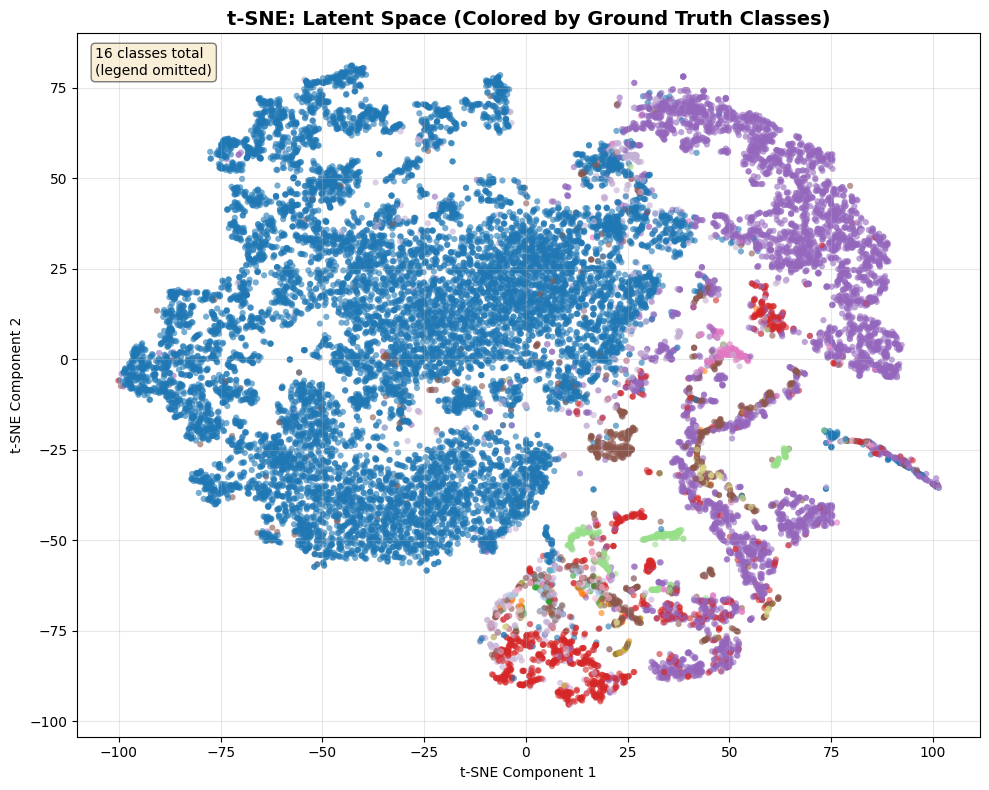


✓ Visualization complete. Latent dimensions: 128


In [39]:
# 5.2 Latent Space Visualization (t-SNE and UMAP)
from sklearn.manifold import TSNE
import matplotlib.cm as cm
import matplotlib.patches as mpatches

# Prepare normalized latent space for visualization
scaler_viz = StandardScaler()
latent_normalized_viz = scaler_viz.fit_transform(latent_flat)

# Create color map for all classes
unique_classes = df['class'].unique()
n_classes = len(unique_classes)
colors_map = cm.get_cmap('tab20', n_classes)
class_to_color = {cls: colors_map(i) for i, cls in enumerate(unique_classes)}
colors_by_class = [class_to_color[cls] for cls in df['class']]

print("Computing dimensionality reductions for visualization...")

# ============================================================================
# t-SNE Embedding
# ============================================================================
print("  - Computing t-SNE (this may take 1-2 minutes)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
tsne_embedding = tsne.fit_transform(latent_normalized_viz)
print("  ✓ t-SNE complete")

# ============================================================================
# UMAP Embedding (if available)
# ============================================================================
try:
    import umap
    print("  - Computing UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_embedding = umap_reducer.fit_transform(latent_normalized_viz)
    print("  ✓ UMAP complete")
    has_umap = True
except ImportError:
    print("  ⚠ UMAP not installed (pip install umap-learn). Skipping UMAP visualization.")
    has_umap = False

# ============================================================================
# Plotting
# ============================================================================
n_plots = 2 if has_umap else 1
fig, axes = plt.subplots(1, n_plots, figsize=(10*n_plots, 8))
if n_plots == 1:
    axes = [axes]

# Plot 1: t-SNE colored by ground truth
ax = axes[0]
scatter = ax.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], 
                     c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
ax.set_title('t-SNE: Latent Space (Colored by Ground Truth Classes)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.grid(True, alpha=0.3)

# Create legend (limit to reasonable number of classes)
if n_classes <= 15:
    patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
               for cls in unique_classes]
    ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
              fontsize=8, framealpha=0.9)
else:
    ax.text(0.02, 0.98, f'{n_classes} classes total\n(legend omitted)', 
            transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: UMAP colored by ground truth (if available)
if has_umap:
    ax = axes[1]
    scatter = ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], 
                         c=colors_by_class, s=20, alpha=0.6, edgecolors='none')
    ax.set_title('UMAP: Latent Space (Colored by Ground Truth Classes)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('UMAP Component 1')
    ax.set_ylabel('UMAP Component 2')
    ax.grid(True, alpha=0.3)
    
    if n_classes <= 15:
        patches = [mpatches.Patch(color=class_to_color[cls], label=cls) 
                   for cls in unique_classes]
        ax.legend(handles=patches, loc='best', ncol=2 if n_classes > 8 else 1, 
                  fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete. Latent dimensions: {latent_flat.shape[1]}")